
# Práctica 4: Redes neuronales con Regularización
## El sobreajuste (overfitting)
El problema del sobreajuste (*overfitting*) consiste en que la solución aprendida se ajusta muy bien a los datos de entrenamiento, pero no generaliza adecuadamente ante la aparición de nuevos datos.

Para observar el sobreajuste en un problema, revisitaremos el problema de clasificación con datos del Titanic que hemos utilizado en los anteriores laboratorios. En primer lugar, carga los datos tal como se hacía en los anteriores notebooks. Asegúrate de tener una partición de entrenamiento con el 50\% de los datos y una de test con el 25\% y una de validación con el 25\% restante. Utiliza la función [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) de `sklearn` sobre el `ndarray` de datos en dos veces sucesivas para conseguir las particiones. Después pasa los conjuntos resultantes a `torch` y envuélvelos en un `Dataloader` como se hacía en el laboratorio anterior.

**IMPORTANTE:** La separación de conjuntos debe hacerse sobre los datos sin preprocesar. Todo preprocesado se debe hacer sobre cada conjunto por separado, pero utilizando solo información del conjunto de entrenamiento. **Revisa la carga de datos de Titanic** para que la estandarización (paso 4 de la función de carga de datos) se realice después de la partición. La función devolverá los datos sin escalar y, tras hacer la separación en train/test/val, utilizaremos un único `StandardScaler` con el que haremos `fit_transform` sobre train y `transform` sobre test y val. Así evitaremos que se filtre ningún tipo de información de test/val al entrenamiento.

In [82]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import numpy as np
import seaborn as sns
import pandas as pd
import torch

# TODO - Carga el dataset Titanic en tres dataloaders: train/test/val
def load_titanic(batch_size = 32):
    # Cargamos el dataset Titanic desde seaborn
    df = sns.load_dataset('titanic')

    # 1️⃣ Selección de variables relevantes y limpieza
    # Columnas que vamos a usar
    cols = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']
    df = df[cols].copy()

    # Eliminamos filas con valores faltantes
    df = df.dropna(subset=['age', 'embarked', 'fare'])

    # 2️⃣ Separar etiquetas y características
    y = df['survived'].to_numpy().astype(np.float32)        # etiquetas como float
    X = df.drop(columns=['survived'])

    # 3️⃣ One-hot encoding para todas las variables categóricas
    categorical_cols = ['pclass', 'sex', 'embarked', 'alone']
    X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    # Toma al dataFrame X y crea columnas binarias para cada valor, lo que hace el drop_first = T
    # es hacer que la 1º etiqueta no se codifique: Color [r, g, b] -> [g, b]
    # De este modo r = [0, 0], g = [1, 0], b = [0, 1]

    # 4️⃣ Partición de datos
    # random_state -> semilla ;
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size = 0.25, random_state = 42)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 1/3, random_state = 42)

    # 5️⃣ Variables numéricas (estandarizacion separada en test y val/entr)
    numeric_cols = ['age', 'sibsp', 'parch', 'fare']
    X_train_numeric = X_train[numeric_cols + [c for c in X_train.columns if c not in numeric_cols]].copy()
    X_test_numeric = X_test[numeric_cols + [c for c in X_test.columns if c not in numeric_cols]].copy()
    X_val_numeric = X_val[numeric_cols + [c for c in X_val.columns if c not in numeric_cols]].copy()

    scaler = StandardScaler() # Objeto que normaliza
    X_train_numeric[numeric_cols] = scaler.fit_transform(X_train_numeric[numeric_cols])
    X_test_numeric[numeric_cols] = scaler.transform(X_test_numeric[numeric_cols])
    X_val_numeric[numeric_cols] = scaler.transform(X_val_numeric[numeric_cols])
    # Calcula media y varianza y normaliza las columnas

    # 6️⃣ Convertir a numpy arrays
    X_train_np = X_train_numeric.to_numpy().astype(np.float32)
    y_train_np = y_train.reshape(-1, 1).astype(np.float32)  # reshape(numero de muestras como de filas, 1 unica columna)

    X_test_np = X_test_numeric.to_numpy().astype(np.float32)
    y_test_np = y_test.reshape(-1, 1).astype(np.float32)

    X_val_np = X_val_numeric.to_numpy().astype(np.float32)
    y_val_np = y_val.reshape(-1, 1).astype(np.float32)

    # 7️⃣ Convertir a Data Loader
    train_dataset = torch.utils.data.TensorDataset(torch.from_numpy(X_train_np), torch.from_numpy(y_train_np))
    test_dataset = torch.utils.data.TensorDataset(torch.from_numpy(X_test_np), torch.from_numpy(y_test_np))
    val_dataset = torch.utils.data.TensorDataset(torch.from_numpy(X_val_np), torch.from_numpy(y_val_np))

    train_dl = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
    test_dl = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)
    val_dl = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)

    return train_dl, test_dl, val_dl

Una vez hayas cargado los datos, vamos a diseñar dos funciones para entrenar y evaluar un modelo. Las funciones deben tener esta forma:
- `def measure_model(model:nn.Module, loss_fn:nn.modules.loss._Loss, data_loader:data.DataLoader) -> tuple[float, float]:`
    - Devuelve una tupla con la pérdida y la accuracy en el conjunto pasado como parámetro. Asegúrate de poner el modelo en modo `eval`.
- `def train_model(model:nn.Module,
                optimizer:optim.Optimizer,
                train_loader:data.DataLoader,
                loss_fn:nn.modules.loss._Loss,
                num_epochs:int,
                val_loader:data.DataLoader,
                patience:None|int=None) -> tuple[tuple[list[int], list[int]]:`
    - Entrena el modelo con los datos de `train_loader` y devuelve una tupla con el histórico de losses en `train_loader` y en `val_loader`. Asegúrate de poner el modelo en modo `train`.

In [83]:
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

def measure_model(model:nn.Module, loss_fn:nn.modules.loss._Loss, data_loader:data.DataLoader) -> tuple[float, float]:
    #TODO Completa la función
    model.eval() # Pone el modelo en modo evaluacion para que se comporte de manera consistente
    loss = 0
    accuracy = 0

    # Bucle de evaluación
    with torch.no_grad(): # No calculamos gradientes
      for inputs, targets in data_loader:
          outputs = model(inputs) # pasamos los datos de entrada por el modelo
          loss += loss_fn(outputs, targets).item() # suma la perdida de esta iteracion
          # .item() en NumPy y PyTorch devuelven como int o float de python
          accuracy += (outputs.round() == targets).sum().item() / len(targets) # Suma el accuracy en los targets de la iteración
    # Promedia los resultados
    loss /= len(data_loader)
    accuracy /= len(data_loader)

    return loss, accuracy

def train_model(model:nn.Module, optimizer:optim.Optimizer, train_loader:data.DataLoader,
                loss_fn:nn.modules.loss._Loss, num_epochs:int, val_loader:data.DataLoader=None, ) -> tuple[tuple[list[int], list[int]]]:

    #TODO Completa la función

    train_loss = None # inicializo la variable que almacenará la pérdida
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):

      model.train() # Pone el modelo en modo entrenamiento
      epoch_loss = 0 # almacena las perdidas de cada elemento

      for inputs, targets in train_loader:
        # Inicializo los gradientes a 0 para que no se acumulen
        optimizer.zero_grad()

        outputs = model(inputs)
        train_loss = loss_fn(outputs, targets)

        # Calcula el gradiente de la pérdida respecto a cada parámetro del modelo
        train_loss.backward()
        # Actualiza los pesos
        optimizer.step()

        epoch_loss += train_loss.item()

      # perdida media del epoch
      epoch_loss /= len(train_loader)
      train_losses.append(epoch_loss)
      print(f"Epoch {epoch + 1}/{num_epochs}, Train loss: {epoch_loss:.3f}")

      # En caso de poner un conjunto de entrenamiento
      if val_loader is not None:
        # Pérdida sobre todo el conjunto de validación (modo eval y sin gradientes)
        val_loss, _ = measure_model(model, loss_fn, val_loader)
        val_losses.append(val_loss)
        print(f"Epoch {epoch + 1}/{num_epochs}, Validation loss: {val_loss:.3f}")

    return train_losses, val_losses

Para este primer apartado, diseña una red neuronal totalmente conectada con tres capas ocultas de 20, 10 y 5 neuronas respectivamente.

In [84]:
import torch
#TODO Define la subclase de nn.Module con la arquitectura descrita
class FullyConnected(nn.Module) :
  def __init__(self, input_dim, output_dim) :
    super().__init__()
    self.fc1 = nn.Linear(input_dim, 20)
    self.fc2 = nn.Linear(20, 10)
    self.fc3 = nn.Linear(10, 5)
    self.out = nn.Linear(5, output_dim)

  def forward(self, x) :
    h0 = torch.relu(self.fc1(x))
    h1 = torch.relu(self.fc2(h0))
    h2 = torch.relu(self.fc3(h1))
    y = torch.sigmoid(self.out(h2))# sigmoide para obtener probabilidad (BCELoss)

    return y

Ahora entrena el modelo utilizando el optimizador `Adam` y la función de coste `BCELoss`. Tras entrenar, calcula la accuracy en test y muestra con `matplotlib` la curva de entrenamiento.

Epoch 1/700, Train loss: 0.698
Epoch 1/700, Validation loss: 0.695
Epoch 2/700, Train loss: 0.695
Epoch 2/700, Validation loss: 0.694
Epoch 3/700, Train loss: 0.694
Epoch 3/700, Validation loss: 0.693
Epoch 4/700, Train loss: 0.692
Epoch 4/700, Validation loss: 0.692
Epoch 5/700, Train loss: 0.691
Epoch 5/700, Validation loss: 0.691
Epoch 6/700, Train loss: 0.690
Epoch 6/700, Validation loss: 0.690
Epoch 7/700, Train loss: 0.688
Epoch 7/700, Validation loss: 0.688
Epoch 8/700, Train loss: 0.687
Epoch 8/700, Validation loss: 0.687
Epoch 9/700, Train loss: 0.685
Epoch 9/700, Validation loss: 0.685
Epoch 10/700, Train loss: 0.683
Epoch 10/700, Validation loss: 0.683
Epoch 11/700, Train loss: 0.681
Epoch 11/700, Validation loss: 0.681
Epoch 12/700, Train loss: 0.677
Epoch 12/700, Validation loss: 0.677
Epoch 13/700, Train loss: 0.673
Epoch 13/700, Validation loss: 0.672
Epoch 14/700, Train loss: 0.670
Epoch 14/700, Validation loss: 0.663
Epoch 15/700, Train loss: 0.660
Epoch 15/700, Valida

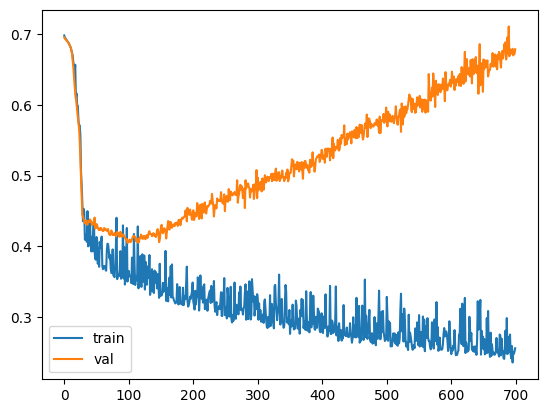

Test loss:1.9956	Test accuracy:0.79


In [85]:
import matplotlib.pyplot as pyplot

train_dl, test_dl, val_dl = load_titanic()

# Obtenemos el número de columnas del conjunto de entrenamiento
n_cols_train = train_dl.dataset.tensors[0].shape[1]
lr = 1e-3 # learning rate

model = FullyConnected(n_cols_train, 1)
# print(model)

# Definimos la función de pérdida y el optimizador
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr = lr)

num_epochs = 700

train_losses, val_losses = train_model(model, optimizer, train_dl, loss_fn, num_epochs, val_dl)

pyplot.plot(train_losses, label="train")
pyplot.plot(val_losses, label="val")
pyplot.legend()
pyplot.show()

test_loss, test_accuracy = measure_model(model, loss_fn, test_dl)

print(f'Test loss:{test_loss:.4f}\tTest accuracy:{test_accuracy:.2f}')

En la curva de entrenamiento deberías ser capaz de identificar que hay sobreentrenamiento porque la curva de validación llega a un punto que deja de mejorar y comienza a empeorar.

*NOTA: Puedes exagerar el efecto de sobreajuste tomando menos datos de entrenamiento, lo cual facilita su memorización.*

# Regularización
Una vez diagnosticado el sobreajuste, es hora de probar diferentes técnicas que intenten reducir la varianza, sin incrementar demasiado el sesgo y, con ello, el modelo generaliza mejor. Las técnicas de regularización que vamos a ver en este laboratorio son:
1. *Early stopping*. Detiene el entrenamiento de la red cuando aumenta el error.
1. Penalización basada	en	la	norma	de	los	parámetros (tanto norma L1 como L2).
1. *Dropout*. Ampliamente utilizada en aprendizaje profundo, "desactiva" algunas neuronas para evitar el sobreajuste.

## Parte 1. Early Stopping
Hacer parada temprana (*early stopping*) consiste en monitorizar el rendimiento en un pequeño subconjunto del conjunto de entrenamiento y parar el aprendizaje cuando este rendimiento decaiga.

Para llevarlo a cabo, añade a la función de `train_model` un parámetro opcional llamado `patience` que indique durantos cuántos pasos puede empeorar el la pérdida en validación sin que se pare el entrenamiento. Cuando esté presente el valor de `patience` el entrenamiento se tiene que parar atendiendo a él.

Una vez tengas la función, vuelve a declarar el modelo y optimizador, entrena y revisa las curvas y el rendimiento en test.

In [86]:
# TODO - Instancia un modelo y un optimizador, haz el entrenamiento con early stopping y muestra las curvas y medidas

# Parte 2. Penalización basada en norma de parámetros
Otra alternativa para regularizar consiste en añadir a la función de pérdida una componente que penalice los valores altos en los parámetros. En `torch` le podemos indicar al optimizador que incluya una penalización L2 en los pesos indicando el parámetro `weight_decay` al instanciarlo. Prueba distintos valores (suele ser buena política probar cambios en factores de 10 alrededor del 0.001) y comprueba su efecto en el rendimiento. No utilices *early stopping* en el entrenamiento.

**¿Qué diferencia observas en la curva de entrenamiento con respecto a utilizar *early stopping*?**

In [87]:
# TODO - Instancia un modelo y un optimizador con weight decay, haz el entrenamiento y muestra las curvas y medidas

# Parte 3. Dropout
Por último, la tercera alternativa que exploraremos para regularizar es añadir capas `nn.Dropout` a nuestra arquitectura. Estas capas apagan durante el entrenamiento una fracción (que debemos indicar como parámetro al instanciar la capa) de las neuronas que reciben a la entrada, impidiendo al modelo apoyarse siempre en las mismas entradas para hacer sus predicciones, forzándolo así a aprender representaciones más generales y, por tanto, mejorando su generalización.

Crea una nueva arquitectura de red con estas capas y entrénala (sin usar ningún otro mecanismo de regularización). Prueba a situar las capas `nn.Dropout` en distintos sitios y a aplicar distintos valores del parámetro `p` que indica la probabilidad de que se apague cada neurona.

In [88]:

# TODO - Declara la nueva clase, haz que tu modelo sea una instancia de ella, instancia el optimizador, haz el entrenamiento y muestra las curvas y medidas.